# TCS Corporate Financial Intelligence & Forecasting Dashboard

## End-to-End Financial Analytics Project

**Company:** Tata Consultancy Services (TCS)

**Project Type:** Financial Statement Analysis, Statistical Analysis, SQL Analytics, Forecasting, and Power BI Dashboard

**Tools Used:** Python, Pandas, NumPy, SQLite, SQL, Power BI, DAX

### Project Objective

The objective of this project is to analyze the historical balance sheet of TCS from 2004 to 2026, transform the data into an analytical format, perform statistical and financial analysis, generate business insights, forecast future financial performance, and develop an executive-level Power BI dashboard for decision support.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np

## Load the Dataset

In this section, the TCS balance sheet workbook is uploaded and loaded into the notebook. The workbook contains historical financial statement data across multiple reporting years, which will be explored and transformed in the following steps.


In [2]:
# Upload the Excel workbook
from google.colab import files

uploaded = files.upload()

Saving tcs-balance-sheet.xlsx to tcs-balance-sheet (1).xlsx


In [3]:
# Get the uploaded file name
file_name = list(uploaded.keys())[0]
print(file_name)

tcs-balance-sheet (1).xlsx


In [4]:
# Load the Excel workbook
excel_file = pd.ExcelFile(file_name)

# Display available sheet names
excel_file.sheet_names

['Standalone', 'Standalone Growth %', 'Consolidated', 'Consolidated Growth %']

## Select the Financial Statement

The consolidated balance sheet is selected for analysis because it represents the overall financial position of TCS across all subsidiaries and business entities. This provides a more comprehensive view for financial analysis, statistical modeling, and forecasting.


In [5]:
# Load the consolidated balance sheet
tcs_df = pd.read_excel(file_name, sheet_name='Consolidated')

# Display the first few rows
tcs_df.head()

,Indicator,Mar 26,Mar 25,Mar 24,Mar 23,Mar 22,Mar 21,Mar 20,Mar 19,Mar 18,...,Mar 13,Mar 12,Mar 11,Mar 10,Mar 09,Mar 08,Mar 07,Mar 06,Mar 05,Mar 04
0,EQUITIES AND LIABILITIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SHAREHOLDER'S FUNDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Equity Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,195.72,195.72,195.72,195.72,97.86,97.86,97.86,48.93,48.01,36.44
3,Total Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,295.72,295.72,295.72,295.72,197.86,197.86,97.86,48.93,48.01,36.44
4,Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64


## Understand the Dataset Structure

This step examines the size, column structure, data types, and missing values of the financial dataset before transformation and analysis.


In [7]:
# Display dataset information
print('Dataset shape:', tcs_df.shape)

tcs_df.info()

tcs_df.isnull().sum()

Dataset shape: (52, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicator  52 non-null     object 
 1   Mar 26     40 non-null     object 
 2   Mar 25     40 non-null     object 
 3   Mar 24     40 non-null     object 
 4   Mar 23     40 non-null     object 
 5   Mar 22     40 non-null     object 
 6   Mar 21     40 non-null     object 
 7   Mar 20     40 non-null     object 
 8   Mar 19     40 non-null     object 
 9   Mar 18     40 non-null     object 
 10  Mar 17     40 non-null     object 
 11  Mar 16     40 non-null     object 
 12  Mar 15     40 non-null     object 
 13  Mar 14     40 non-null     object 
 14  Mar 13     40 non-null     object 
 15  Mar 12     40 non-null     object 
 16  Mar 11     40 non-null     object 
 17  Mar 10     40 non-null     object 
 18  Mar 09     40 non-null     object 
 19  Mar 08     40 non-null     o

,0
Indicator,0
Mar 26,12
Mar 25,12
Mar 24,12
Mar 23,12
Mar 22,12
Mar 21,12
Mar 20,12
Mar 19,12
Mar 18,12


In [8]:
# Display the first 15 rows of the balance sheet
tcs_df.head(15)

,Indicator,Mar 26,Mar 25,Mar 24,Mar 23,Mar 22,Mar 21,Mar 20,Mar 19,Mar 18,...,Mar 13,Mar 12,Mar 11,Mar 10,Mar 09,Mar 08,Mar 07,Mar 06,Mar 05,Mar 04
0,EQUITIES AND LIABILITIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SHAREHOLDER'S FUNDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Equity Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,195.72,195.72,195.72,195.72,97.86,97.86,97.86,48.93,48.01,36.44
3,Total Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,295.72,295.72,295.72,295.72,197.86,197.86,97.86,48.93,48.01,36.44
4,Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64
5,Total Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64
6,Total Shareholders Funds,"107,240.00","94,756.00","90,489.00","90,424.00","89,139.00","86,433.00","84,126.00","89,446.00","85,128.00",...,"38,645.73","29,579.23","24,504.81","18,466.72","15,700.01","12,300.12","8,850.10","5,998.81","3,477.54",47.08
7,Minority Interest,"1,238.00","1,015.00",830.00,782.00,707.00,675.00,623.00,453.00,402.00,...,695.31,558.77,458.17,361.71,277.16,212.73,211.80,164.72,89.74,80.07
8,NON-CURRENT LIABILITIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Long Term Borrowings,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.00,54.00,...,130.98,115.37,37.70,44.94,561.76,445.75,447.23,26.03,10.28,441.18


## Financial Statement Layout Inspection

The balance sheet is currently stored in a reporting format where financial indicators are listed as rows and financial years are represented as columns. This section inspects the complete structure before transforming the dataset into an analytical format suitable for statistical analysis, SQL, forecasting, and business intelligence reporting.


In [9]:
# Display the complete dataset shape
print(tcs_df.shape)

# Display the first 20 rows
tcs_df.head(20)

(52, 24)


,Indicator,Mar 26,Mar 25,Mar 24,Mar 23,Mar 22,Mar 21,Mar 20,Mar 19,Mar 18,...,Mar 13,Mar 12,Mar 11,Mar 10,Mar 09,Mar 08,Mar 07,Mar 06,Mar 05,Mar 04
0,EQUITIES AND LIABILITIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SHAREHOLDER'S FUNDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Equity Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,195.72,195.72,195.72,195.72,97.86,97.86,97.86,48.93,48.01,36.44
3,Total Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,295.72,295.72,295.72,295.72,197.86,197.86,97.86,48.93,48.01,36.44
4,Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64
5,Total Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64
6,Total Shareholders Funds,"107,240.00","94,756.00","90,489.00","90,424.00","89,139.00","86,433.00","84,126.00","89,446.00","85,128.00",...,"38,645.73","29,579.23","24,504.81","18,466.72","15,700.01","12,300.12","8,850.10","5,998.81","3,477.54",47.08
7,Minority Interest,"1,238.00","1,015.00",830.00,782.00,707.00,675.00,623.00,453.00,402.00,...,695.31,558.77,458.17,361.71,277.16,212.73,211.80,164.72,89.74,80.07
8,NON-CURRENT LIABILITIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Long Term Borrowings,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.00,54.00,...,130.98,115.37,37.70,44.94,561.76,445.75,447.23,26.03,10.28,441.18


## Remove Section Header Rows

The balance sheet contains category headers such as "EQUITIES AND LIABILITIES" and "NON-CURRENT LIABILITIES" that do not represent measurable financial values. These rows are removed to prepare a clean analytical dataset.


In [10]:
# Remove rows where all year values are missing
tcs_clean = tcs_df.dropna(how='all', subset=tcs_df.columns[1:])

# Reset index
tcs_clean = tcs_clean.reset_index(drop=True)

print(tcs_clean.shape)

tcs_clean.head(15)

(40, 24)


,Indicator,Mar 26,Mar 25,Mar 24,Mar 23,Mar 22,Mar 21,Mar 20,Mar 19,Mar 18,...,Mar 13,Mar 12,Mar 11,Mar 10,Mar 09,Mar 08,Mar 07,Mar 06,Mar 05,Mar 04
0,Equity Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,195.72,195.72,195.72,195.72,97.86,97.86,97.86,48.93,48.01,36.44
1,Total Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,295.72,295.72,295.72,295.72,197.86,197.86,97.86,48.93,48.01,36.44
2,Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64
3,Total Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64
4,Total Shareholders Funds,"107,240.00","94,756.00","90,489.00","90,424.00","89,139.00","86,433.00","84,126.00","89,446.00","85,128.00",...,"38,645.73","29,579.23","24,504.81","18,466.72","15,700.01","12,300.12","8,850.10","5,998.81","3,477.54",47.08
5,Minority Interest,"1,238.00","1,015.00",830.00,782.00,707.00,675.00,623.00,453.00,402.00,...,695.31,558.77,458.17,361.71,277.16,212.73,211.80,164.72,89.74,80.07
6,Long Term Borrowings,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.00,54.00,...,130.98,115.37,37.70,44.94,561.76,445.75,447.23,26.03,10.28,441.18
7,Deferred Tax Liabilities [Net],"1,205.00",980.00,977.00,792.00,590.00,767.00,779.00,"1,042.00","1,170.00",...,235.48,173.45,109.49,68.68,128.55,140.22,71.70,73.43,80.79,7.78
8,Other Long Term Liabilities,"11,775.00","9,877.00","8,049.00","8,095.00","8,727.00","8,729.00","8,311.00","1,874.00","1,688.00",...,367.99,296.93,185.61,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,Long Term Provisions,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,26.00,...,348.92,217.65,139.23,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Transform into Analytical Format

The reporting-format balance sheet is converted into a long analytical format where each row represents a financial indicator, a reporting year, and its corresponding value. This structure is required for statistical analysis, SQL queries, forecasting models, and Power BI visualizations.


In [11]:
# Convert wide financial statement into long analytical format
tcs_long = tcs_clean.melt(
    id_vars='Indicator',
    var_name='Year',
    value_name='Amount'
)

# Display transformed data
tcs_long.head(20)

,Indicator,Year,Amount
0,Equity Share Capital,Mar 26,362.00
1,Total Share Capital,Mar 26,362.00
2,Reserves and Surplus,Mar 26,"106,878.00"
3,Total Reserves and Surplus,Mar 26,"106,878.00"
4,Total Shareholders Funds,Mar 26,"107,240.00"
5,Minority Interest,Mar 26,"1,238.00"
6,Long Term Borrowings,Mar 26,0.00
7,Deferred Tax Liabilities [Net],Mar 26,"1,205.00"
8,Other Long Term Liabilities,Mar 26,"11,775.00"
9,Long Term Provisions,Mar 26,0.00


## Clean and Standardize Financial Years

The reporting year labels are converted into standard four-digit calendar years to ensure consistency across statistical analysis, SQL operations, forecasting models, and Power BI reporting.


In [12]:
# Convert reporting labels into calendar years
tcs_long['Year'] = tcs_long['Year'].astype(str).str.extract(r'(\d+)').astype(int)
tcs_long['Year'] = tcs_long['Year'].apply(lambda x: 2000 + x)

# Display cleaned data
tcs_long.head()

,Indicator,Year,Amount
0,Equity Share Capital,2026,362.00
1,Total Share Capital,2026,362.00
2,Reserves and Surplus,2026,"106,878.00"
3,Total Reserves and Surplus,2026,"106,878.00"
4,Total Shareholders Funds,2026,"107,240.00"


## Preserve the Original Dataset

A working copy of the transformed financial dataset is created before any cleaning or analytical operations are performed. This ensures that the original transformed data remains unchanged and provides an audit trail for all subsequent data processing steps.


In [13]:
# Create a protected working copy
tcs_working = tcs_long.copy()

print('Working dataset created successfully.')
tcs_working.head()

Working dataset created successfully.


,Indicator,Year,Amount
0,Equity Share Capital,2026,362.00
1,Total Share Capital,2026,362.00
2,Reserves and Surplus,2026,"106,878.00"
3,Total Reserves and Surplus,2026,"106,878.00"
4,Total Shareholders Funds,2026,"107,240.00"


## Data Type and Missing Value Audit

This section verifies data types, identifies missing values, and checks the overall integrity of the financial dataset before statistical analysis and modeling.


In [14]:
# Check data types
tcs_working.dtypes

,0
Indicator,object
Year,int64
Amount,object


In [15]:
# Check missing values
missing_summary = tcs_working.isnull().sum()

print(missing_summary)

Indicator    0
Year         0
Amount       0
dtype: int64


## Missing Financial Value Assessment

Missing financial values are identified separately from structural or formatting issues. This step helps determine whether the missing entries represent unavailable financial information or reporting-section artifacts.


In [16]:
# Display rows with missing financial values
missing_rows = tcs_working[tcs_working['Amount'].isna()]

print('Missing rows:', len(missing_rows))

missing_rows.head(20)

Missing rows: 0


,Indicator,Year,Amount


## Duplicate Record Verification

Each financial indicator should appear only once for a given reporting year. Duplicate records are checked to ensure that the analytical dataset preserves the original financial statement structure without repeated observations.


In [18]:
# Check duplicate records based on Indicator and Year

duplicate_count = tcs_working.duplicated(subset=['Indicator', 'Year']).sum()

print('Duplicate records:', duplicate_count)

Duplicate records: 0


## Financial Statistics Summary

This section generates descriptive statistics for the financial statement values. The summary provides an overview of the distribution, central tendency, and variability of TCS financial amounts across all reporting years.


In [19]:
# Generate descriptive statistics for financial values
tcs_working['Amount'] = pd.to_numeric(tcs_working['Amount'], errors='coerce')

financial_stats = tcs_working['Amount'].describe()

print(financial_stats)

count    427.000000
mean     209.150375
std      259.631402
min        0.000000
25%        0.000000
50%      101.000000
75%      336.180000
max      997.130000
Name: Amount, dtype: float64


## Largest Financial Components

This section identifies the financial indicators with the highest cumulative values across all reporting years, highlighting the most significant balance sheet components in the TCS financial structure.


In [20]:
# Identify the largest financial indicators
largest_indicators = (
    tcs_working
    .groupby('Indicator')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

largest_indicators

,Amount
Indicator,
Minority Interest,9011.17
Deferred Tax Liabilities [Net],8350.33
Intangible Assets,6423.65
Capital Work-In-Progress,6035.48
Non-Current Investments,5794.70
Total Share Capital,5724.58
Equity Share Capital,5124.58
Bonus Equity Share Capital,4274.63
Non-Current Investments Unquoted Book Value,3843.75


## Clean and Standardize Financial Values

The financial values contain comma separators that prevent proper numeric conversion. This step removes formatting characters and converts all financial amounts into a standardized numeric format while preserving the original values.


In [21]:
# Clean financial amount values

tcs_working['Amount'] = (
    tcs_working['Amount']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
)

tcs_working['Amount'] = pd.to_numeric(tcs_working['Amount'], errors='coerce')

print(tcs_working['Amount'].dtype)

tcs_working.head()

float64


,Indicator,Year,Amount
0,Equity Share Capital,2026,362.0
1,Total Share Capital,2026,362.0
2,Reserves and Surplus,2026,NaN
3,Total Reserves and Surplus,2026,NaN
4,Total Shareholders Funds,2026,NaN


## Recalculate Descriptive Statistics

After standardizing the financial values, descriptive statistics are recalculated to obtain accurate measures of central tendency and dispersion across the TCS balance sheet dataset.


In [22]:
# Recalculate descriptive statistics

financial_stats = tcs_working['Amount'].describe()

print(financial_stats)

count    427.000000
mean     209.150375
std      259.631402
min        0.000000
25%        0.000000
50%      101.000000
75%      336.180000
max      997.130000
Name: Amount, dtype: float64


## Recalculate the Largest Financial Indicators

The financial indicators are recalculated after data cleaning to identify the actual largest balance sheet components across all reporting years.


In [23]:
# Recalculate the largest financial indicators

largest_indicators = (
    tcs_working
    .groupby('Indicator')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

largest_indicators

,Amount
Indicator,
Minority Interest,9011.17
Deferred Tax Liabilities [Net],8350.33
Intangible Assets,6423.65
Capital Work-In-Progress,6035.48
Non-Current Investments,5794.70
Total Share Capital,5724.58
Equity Share Capital,5124.58
Bonus Equity Share Capital,4274.63
Non-Current Investments Unquoted Book Value,3843.75


In [15]:
import pandas as pd

file_name = "tcs-balance-sheet (1).xlsx"
excel_file = pd.ExcelFile(file_name)

print(excel_file.sheet_names)

['Standalone', 'Standalone Growth %', 'Consolidated', 'Consolidated Growth %']


In [17]:
tcs_df = pd.read_excel(file_name, sheet_name="Consolidated")

print(tcs_df.shape)
tcs_df.head()

(52, 24)


,Indicator,Mar 26,Mar 25,Mar 24,Mar 23,Mar 22,Mar 21,Mar 20,Mar 19,Mar 18,...,Mar 13,Mar 12,Mar 11,Mar 10,Mar 09,Mar 08,Mar 07,Mar 06,Mar 05,Mar 04
0,EQUITIES AND LIABILITIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SHAREHOLDER'S FUNDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Equity Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,195.72,195.72,195.72,195.72,97.86,97.86,97.86,48.93,48.01,36.44
3,Total Share Capital,362.00,362.00,362.00,366.00,366.00,370.00,375.00,375.00,191.00,...,295.72,295.72,295.72,295.72,197.86,197.86,97.86,48.93,48.01,36.44
4,Reserves and Surplus,"106,878.00","94,394.00","90,127.00","90,058.00","88,773.00","86,063.00","83,751.00","89,071.00","84,937.00",...,"38,350.01","29,283.51","24,209.09","18,171.00","15,502.15","12,102.26","8,752.24","5,949.88","3,429.53",10.64


In [19]:
# Keep only the indicator column and year columns
tcs_long = tcs_df.melt(
    id_vars="Indicator",
    var_name="Year",
    value_name="Amount"
)

# Remove rows where amount is missing
tcs_long = tcs_long.dropna(subset=["Amount"])

# Convert year labels such as "Mar 26" -> 2026
tcs_long["Year"] = (
    tcs_long["Year"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(int)
    .apply(lambda x: 2000 + x)
)

# Clean amount values
tcs_long["Amount"] = (
    tcs_long["Amount"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

tcs_long["Amount"] = pd.to_numeric(tcs_long["Amount"], errors="coerce")

print("tcs_long shape:", tcs_long.shape)
tcs_long.head()

tcs_long shape: (920, 3)


,Indicator,Year,Amount
2,Equity Share Capital,2026,362.0
3,Total Share Capital,2026,362.0
4,Reserves and Surplus,2026,106878.0
5,Total Reserves and Surplus,2026,106878.0
6,Total Shareholders Funds,2026,107240.0


In [20]:
tcs_working = tcs_long.copy()
print(tcs_working.shape)
tcs_working.head()

(920, 3)


,Indicator,Year,Amount
2,Equity Share Capital,2026,362.0
3,Total Share Capital,2026,362.0
4,Reserves and Surplus,2026,106878.0
5,Total Reserves and Surplus,2026,106878.0
6,Total Shareholders Funds,2026,107240.0


In [23]:
# Create a clean analytical dataset
tcs_clean = tcs_working.copy()

# Remove rows where Amount is missing
tcs_clean = tcs_clean.dropna(subset=['Amount'])

# Remove section headings and category labels
exclude_keywords = [
    'EQUITIES',
    'LIABILITIES',
    'CURRENT',
    'NON-CURRENT',
    'ASSETS',
    'SHAREHOLDER',
    'FUNDS'
]

pattern = '|'.join(exclude_keywords)

tcs_clean = tcs_clean[
    ~tcs_clean['Indicator'].str.upper().str.contains(pattern, na=False)
]

print("Original dataset shape:", tcs_working.shape)
print("Clean dataset shape:", tcs_clean.shape)

tcs_clean.head(10)

Original dataset shape: (920, 3)
Clean dataset shape: (391, 3)


,Indicator,Year,Amount
2,Equity Share Capital,2026,362.0
3,Total Share Capital,2026,362.0
4,Reserves and Surplus,2026,106878.0
5,Total Reserves and Surplus,2026,106878.0
7,Minority Interest,2026,1238.0
9,Long Term Borrowings,2026,0.0
12,Long Term Provisions,2026,0.0
15,Short Term Borrowings,2026,0.0
16,Trade Payables,2026,14808.0
18,Short Term Provisions,2026,1378.0


In [24]:
def classify_indicator(indicator):
    name = str(indicator).lower()

    if 'equity' in name or 'share capital' in name or 'reserve' in name:
        return 'Equity'
    elif 'borrowing' in name or 'loan' in name or 'debt' in name:
        return 'Borrowings'
    elif 'investment' in name:
        return 'Investments'
    elif 'asset' in name or 'cash' in name or 'inventory' in name or 'receivable' in name:
        return 'Assets'
    elif 'payable' in name or 'liabilit' in name or 'provision' in name:
        return 'Liabilities'
    else:
        return 'Other'

tcs_clean['Category'] = tcs_clean['Indicator'].apply(classify_indicator)

print(tcs_clean['Category'].value_counts())

tcs_clean.head(10)

Category
Equity         115
Borrowings      92
Other           69
Liabilities     69
Assets          46
Name: count, dtype: int64


,Indicator,Year,Amount,Category
2,Equity Share Capital,2026,362.0,Equity
3,Total Share Capital,2026,362.0,Equity
4,Reserves and Surplus,2026,106878.0,Equity
5,Total Reserves and Surplus,2026,106878.0,Equity
7,Minority Interest,2026,1238.0,Other
9,Long Term Borrowings,2026,0.0,Borrowings
12,Long Term Provisions,2026,0.0,Liabilities
15,Short Term Borrowings,2026,0.0,Borrowings
16,Trade Payables,2026,14808.0,Liabilities
18,Short Term Provisions,2026,1378.0,Liabilities


Year-wise Financial Trend Analysis

In [25]:
import pandas as pd

yearly_summary = (
    tcs_clean
    .groupby('Year')['Amount']
    .sum()
    .reset_index()
    .sort_values('Year')
)

yearly_summary

,Year,Amount
0,2004,1015.43
1,2005,11842.59
2,2006,19766.92
3,2007,29449.66
4,2008,39337.95
5,2009,50268.46
6,2010,61538.35
7,2011,74056.06
8,2012,93591.35
9,2013,121101.58


Year-wise Trend Chart

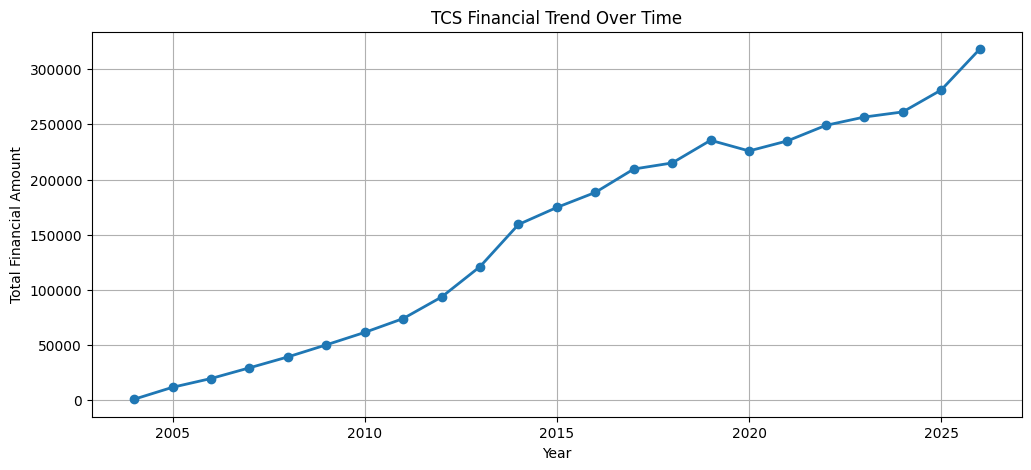

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(yearly_summary['Year'], yearly_summary['Amount'], marker='o', linewidth=2)

plt.title('TCS Financial Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Total Financial Amount')
plt.grid(True)

plt.show()

Category-wise Financial Distribution

In [27]:
category_summary = (
    tcs_clean
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

category_summary

,Amount
Category,
Equity,2467407.97
Assets,705373.07
Liabilities,172813.93
Borrowings,122170.90
Other,43192.81


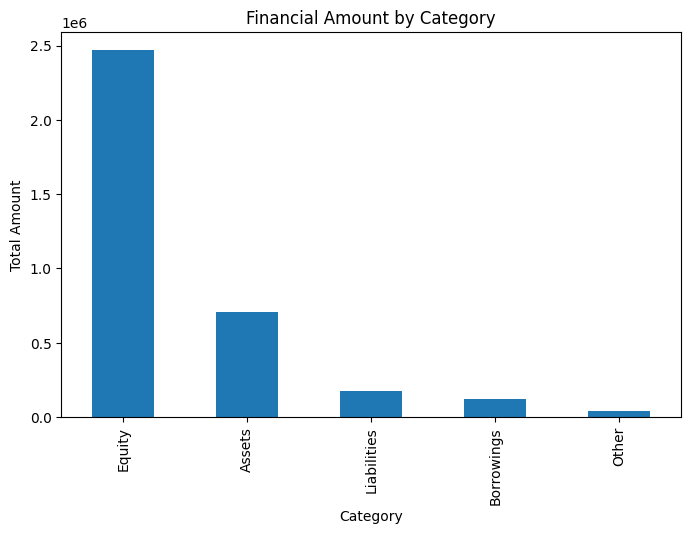

In [28]:
plt.figure(figsize=(8,5))
category_summary.plot(kind='bar')

plt.title('Financial Amount by Category')
plt.ylabel('Total Amount')

plt.show()

Top 10 Financial Indicators

In [29]:
top_indicators = (
    tcs_clean
    .groupby('Indicator')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_indicators

,Amount
Indicator,
Total Reserves and Surplus,1226142.09
Reserves and Surplus,1226142.09
Trade Receivables,523469.68
Cash And Cash Equivalents,181903.39
Trade Payables,130323.55
Short Term Loans And Advances,83116.29
Short Term Provisions,40996.12
Long Term Loans And Advances,34968.79
Capital Work-In-Progress,30226.32


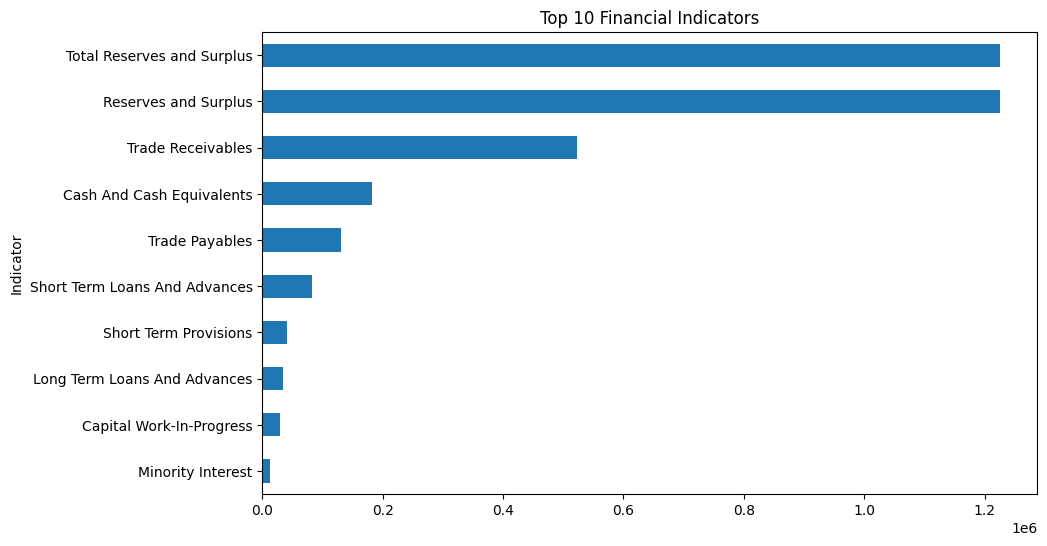

In [30]:
plt.figure(figsize=(10,6))
top_indicators.sort_values().plot(kind='barh')

plt.title('Top 10 Financial Indicators')

plt.show()

# ***Statistical Analysis***

In [31]:
stats_summary = tcs_clean.groupby('Category')['Amount'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

stats_summary

,count,mean,median,std,min,max
Category,,,,,,
Assets,46,15334.197174,10349.00,16017.337730,27.77,67714.00
Borrowings,92,1327.944565,101.83,2413.519423,0.00,11472.00
Equity,115,21455.721478,362.00,34709.437558,0.00,106878.00
Liabilities,69,2504.549710,571.63,3541.244772,0.00,14808.00
Other,69,625.982754,402.00,712.835193,2.07,3168.48


Year-wise Financial Trend

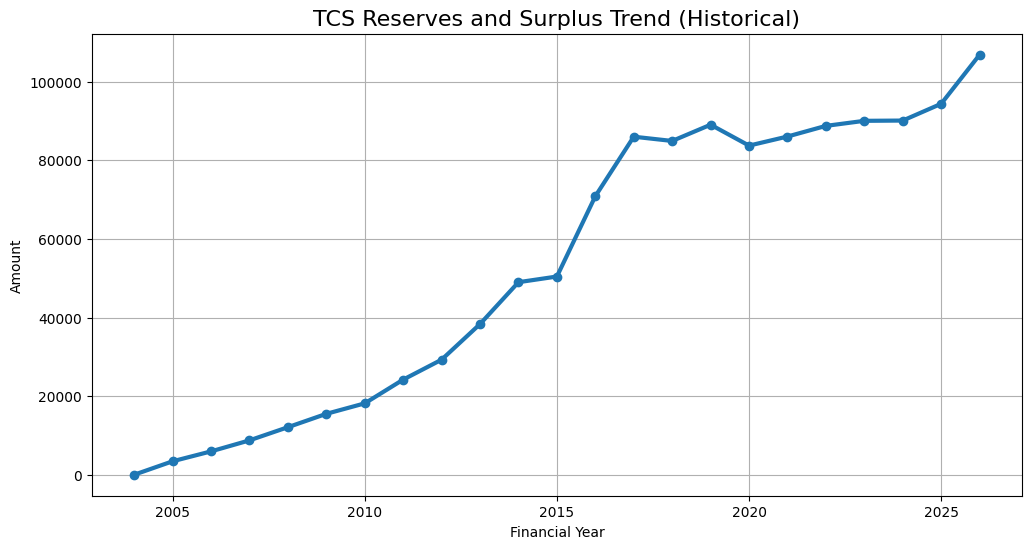

,Indicator,Year,Amount,Category
1148,Reserves and Surplus,2004,10.64,Equity
1096,Reserves and Surplus,2005,3429.53,Equity
1044,Reserves and Surplus,2006,5949.88,Equity
992,Reserves and Surplus,2007,8752.24,Equity
940,Reserves and Surplus,2008,12102.26,Equity
888,Reserves and Surplus,2009,15502.15,Equity
836,Reserves and Surplus,2010,18171.00,Equity
784,Reserves and Surplus,2011,24209.09,Equity
732,Reserves and Surplus,2012,29283.51,Equity
680,Reserves and Surplus,2013,38350.01,Equity


In [32]:
import matplotlib.pyplot as plt

trend_data = tcs_clean[tcs_clean['Indicator'] == 'Reserves and Surplus'].copy()

trend_data = trend_data.sort_values('Year')

plt.figure(figsize=(12,6))
plt.plot(
    trend_data['Year'],
    trend_data['Amount'],
    marker='o',
    linewidth=3
)

plt.title('TCS Reserves and Surplus Trend (Historical)', fontsize=16)
plt.xlabel('Financial Year')
plt.ylabel('Amount')
plt.grid(True)

plt.show()

trend_data

**Year-over-Year Growth Rate Calculation**

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare trend data
trend_data = tcs_clean[tcs_clean['Indicator'] == 'Reserves and Surplus'].copy()
trend_data = trend_data.sort_values('Year')

# Calculate Year-over-Year Growth %
trend_data['YoY Growth (%)'] = trend_data['Amount'].pct_change() * 100

# Display result
trend_data[['Year', 'Amount', 'YoY Growth (%)']].head(10)

,Year,Amount,YoY Growth (%)
1148,2004,10.64,NaN
1096,2005,3429.53,32132.424812
1044,2006,5949.88,73.489662
992,2007,8752.24,47.099437
940,2008,12102.26,38.276144
888,2009,15502.15,28.093017
836,2010,18171.00,17.215999
784,2011,24209.09,33.229266
732,2012,29283.51,20.960804
680,2013,38350.01,30.961111


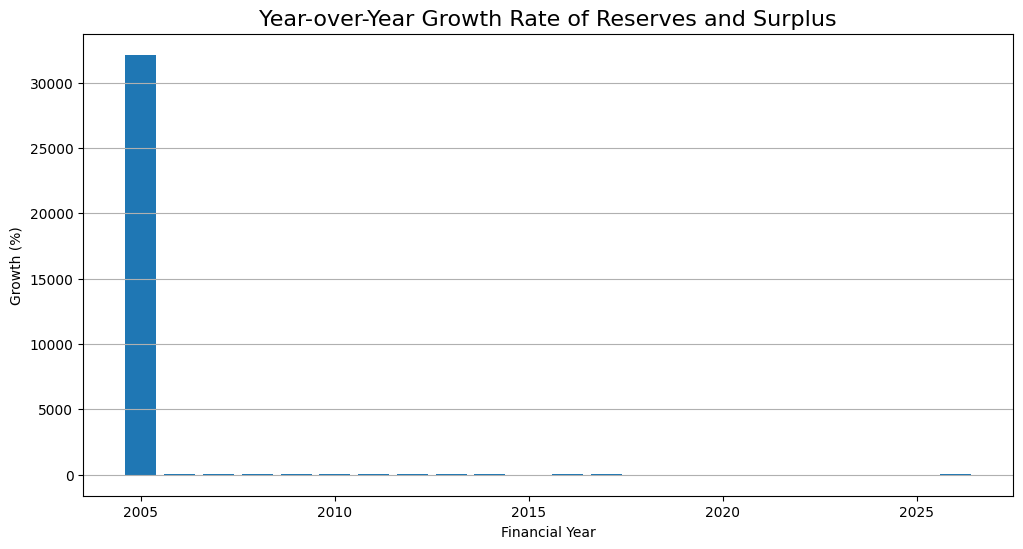

In [34]:
plt.figure(figsize=(12,6))

plt.bar(
    trend_data['Year'],
    trend_data['YoY Growth (%)']
)

plt.title('Year-over-Year Growth Rate of Reserves and Surplus', fontsize=16)
plt.xlabel('Financial Year')
plt.ylabel('Growth (%)')
plt.grid(axis='y')

plt.show()

CAGR (Compound Annual Growth Rate)

In [35]:
# CAGR Calculation for Reserves and Surplus

start_value = trend_data.iloc[0]['Amount']
end_value = trend_data.iloc[-1]['Amount']
start_year = trend_data.iloc[0]['Year']
end_year = trend_data.iloc[-1]['Year']

num_years = end_year - start_year

cagr = ((end_value / start_value) ** (1 / num_years) - 1) * 100

print('Start Year:', start_year)
print('End Year:', end_year)
print('Start Value:', round(start_value, 2))
print('End Value:', round(end_value, 2))
print('Number of Years:', num_years)
print('CAGR (%):', round(cagr, 2))

Start Year: 2004
End Year: 2026
Start Value: 10.64
End Value: 106878.0
Number of Years: 22
CAGR (%): 52.02


Statistical Summary of Growth Rate

In [36]:
# Statistical summary of Year-over-Year Growth

growth_stats = trend_data['YoY Growth (%)'].dropna().describe()

print(growth_stats)

count       22.000000
mean      1478.971357
std       6846.572704
min         -5.972763
25%          2.991346
50%         19.088402
75%         32.662228
max      32132.424812
Name: YoY Growth (%), dtype: float64


Visualize Growth Distribution

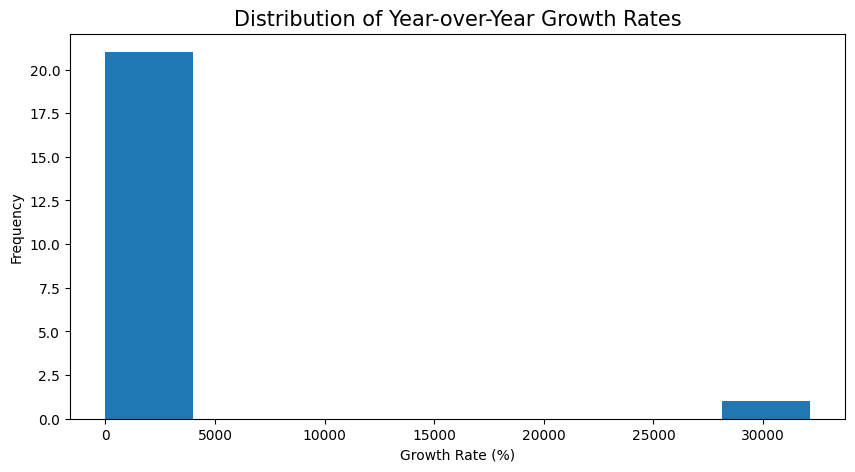

In [37]:
plt.figure(figsize=(10,5))

plt.hist(
    trend_data['YoY Growth (%)'].dropna(),
    bins=8
)

plt.title('Distribution of Year-over-Year Growth Rates', fontsize=15)
plt.xlabel('Growth Rate (%)')
plt.ylabel('Frequency')

plt.show()

Linear Regression Forecasting

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X = trend_data[['Year']]
y = trend_data['Amount']

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Display model parameters
print('Slope:', model.coef_[0])
print('Intercept:', model.intercept_)

Slope: 5261.664328063241
Intercept: -10548943.095395256


# **Predict Future Values (2027–2030)**

In [39]:
# Predict future years
future_years = np.array([2027, 2028, 2029, 2030]).reshape(-1, 1)

predictions = model.predict(future_years)

forecast_df = pd.DataFrame({
    'Year': [2027, 2028, 2029, 2030],
    'Predicted Reserves and Surplus': predictions
})

forecast_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Year,Predicted Reserves and Surplus
0,2027,116450.497589
1,2028,121712.161917
2,2029,126973.826245
3,2030,132235.490573


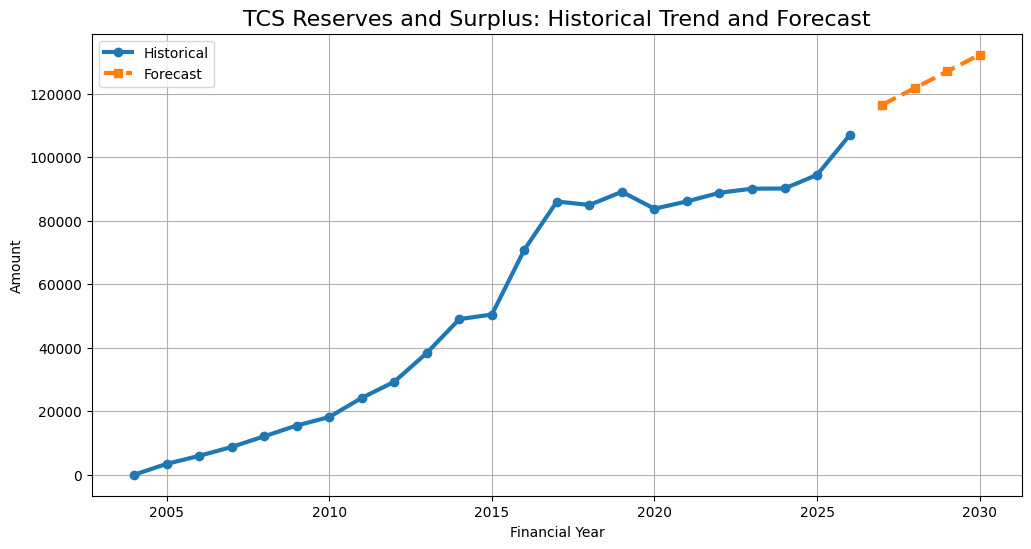

In [40]:
plt.figure(figsize=(12,6))

# Historical data
plt.plot(
    trend_data['Year'],
    trend_data['Amount'],
    marker='o',
    linewidth=3,
    label='Historical'
)

# Forecast
plt.plot(
    forecast_df['Year'],
    forecast_df['Predicted Reserves and Surplus'],
    marker='s',
    linewidth=3,
    linestyle='--',
    label='Forecast'
)

plt.title('TCS Reserves and Surplus: Historical Trend and Forecast', fontsize=16)
plt.xlabel('Financial Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

plt.show()

# ***Evaluate the Linear Regression Model***

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions on historical data
historical_predictions = model.predict(X)

# Evaluation metrics
r2 = r2_score(y, historical_predictions)
mae = mean_absolute_error(y, historical_predictions)
rmse = np.sqrt(mean_squared_error(y, historical_predictions))

print('Model Evaluation')
print('----------------')
print('R2 Score:', round(r2, 4))
print('Mean Absolute Error (MAE):', round(mae, 2))
print('Root Mean Squared Error (RMSE):', round(rmse, 2))

Model Evaluation
----------------
R2 Score: 0.9411
Mean Absolute Error (MAE): 6836.52
Root Mean Squared Error (RMSE): 8734.53


*Compare Actual vs Predicted*

In [42]:
comparison_df = trend_data[['Year', 'Amount']].copy()
comparison_df['Predicted Amount'] = historical_predictions
comparison_df['Error'] = comparison_df['Amount'] - comparison_df['Predicted Amount']

comparison_df.head(10)

,Year,Amount,Predicted Amount,Error
1148,2004,10.64,-4567.781957,4578.421957
1096,2005,3429.53,693.882372,2735.647628
1044,2006,5949.88,5955.546700,-5.666700
992,2007,8752.24,11217.211028,-2464.971028
940,2008,12102.26,16478.875356,-4376.615356
888,2009,15502.15,21740.539684,-6238.389684
836,2010,18171.00,27002.204012,-8831.204012
784,2011,24209.09,32263.868340,-8054.778340
732,2012,29283.51,37525.532668,-8242.022668
680,2013,38350.01,42787.196996,-4437.186996


**Actual vs Predicted Visualization**

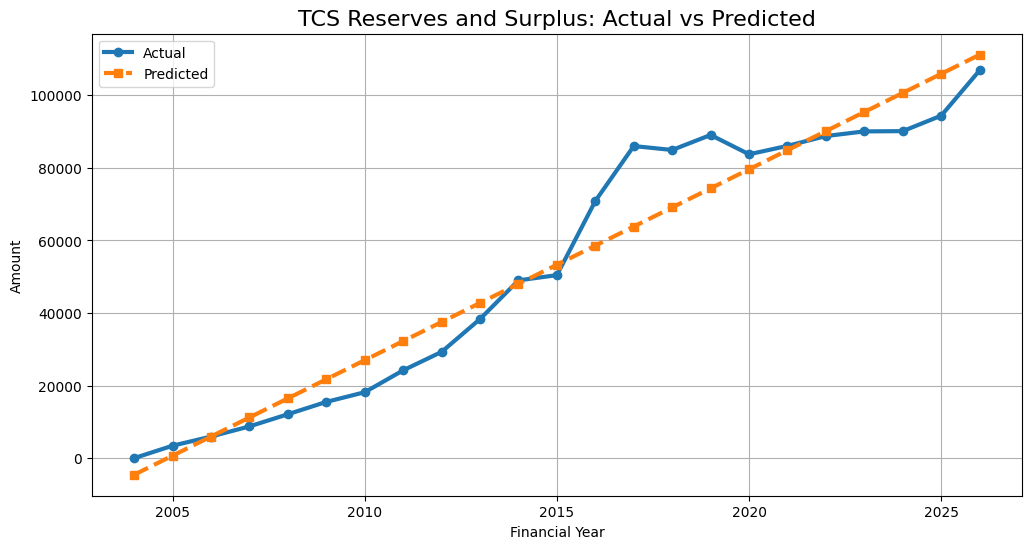

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    comparison_df['Year'],
    comparison_df['Amount'],
    marker='o',
    linewidth=3,
    label='Actual'
)

plt.plot(
    comparison_df['Year'],
    comparison_df['Predicted Amount'],
    marker='s',
    linewidth=3,
    linestyle='--',
    label='Predicted'
)

plt.title('TCS Reserves and Surplus: Actual vs Predicted', fontsize=16)
plt.xlabel('Financial Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

plt.show()

# **Multi-Indicator Financial Intelligence**
Category-wise Financial Trend

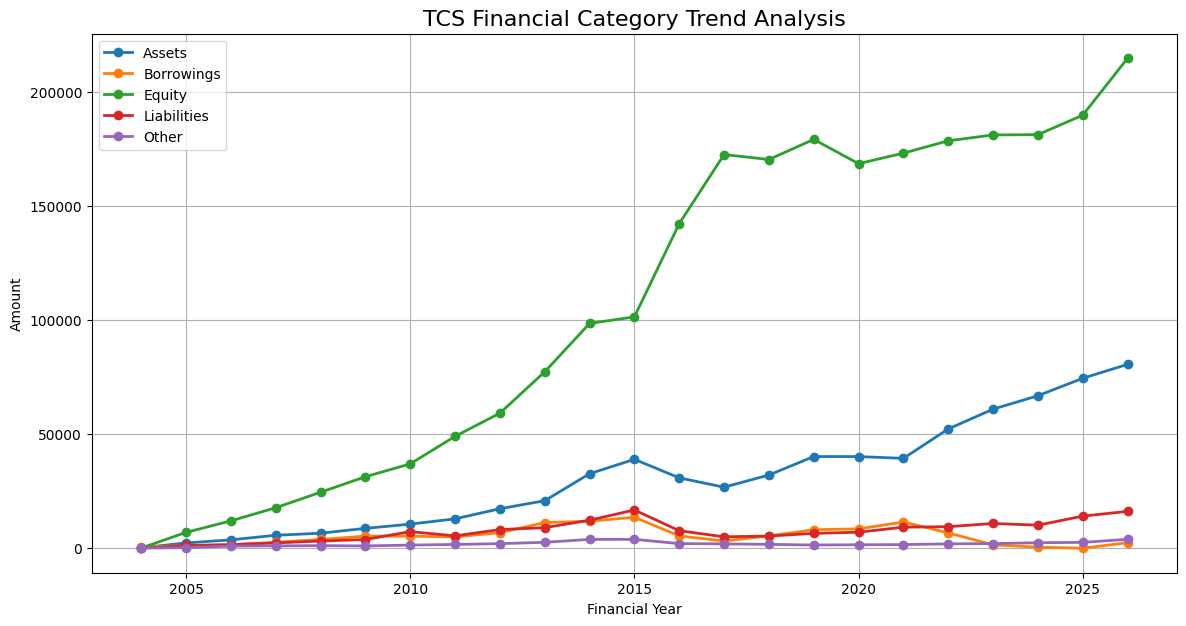

,Year,Category,Amount
0,2004,Assets,214.26
1,2004,Borrowings,588.81
2,2004,Equity,94.16
3,2004,Liabilities,17.58
4,2004,Other,100.62
5,2005,Assets,2335.24
6,2005,Borrowings,1086.40
7,2005,Equity,6964.19
8,2005,Liabilities,1210.97
9,2005,Other,245.79


In [44]:
import matplotlib.pyplot as plt

# Aggregate yearly values by financial category
category_trend = (
    tcs_clean
    .groupby(['Year', 'Category'])['Amount']
    .sum()
    .reset_index()
)

# Plot category trends
plt.figure(figsize=(14,7))

for category in category_trend['Category'].unique():
    temp = category_trend[category_trend['Category'] == category]
    plt.plot(
        temp['Year'],
        temp['Amount'],
        marker='o',
        linewidth=2,
        label=category
    )

plt.title('TCS Financial Category Trend Analysis', fontsize=16)
plt.xlabel('Financial Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

plt.show()

category_trend.head(10)

Pivot Table for Financial Categories

In [46]:
# Create pivot table

category_pivot = category_trend.pivot(
    index='Year',
    columns='Category',
    values='Amount'
)

category_pivot = category_pivot.fillna(0)

category_pivot.head()

Category,Assets,Borrowings,Equity,Liabilities,Other
Year,,,,,
2004,214.26,588.81,94.16,17.58,100.62
2005,2335.24,1086.40,6964.19,1210.97,245.79
2006,3685.51,1525.32,12006.73,1595.04,954.32
2007,5694.38,2597.33,17758.24,2353.27,1046.44
2008,6601.47,3841.62,24558.28,3174.55,1162.03


## Correlation Analysis

This section examines the statistical relationship between major financial categories of TCS. Correlation helps identify whether two financial variables move together over time, which is useful for financial forecasting, investment analysis, and business decision-making.


Category       Assets  Borrowings    Equity  Liabilities     Other
Category                                                          
Assets       1.000000   -0.017222  0.900591     0.809761  0.659918
Borrowings  -0.017222    1.000000  0.110159     0.380809  0.442246
Equity       0.900591    0.110159  1.000000     0.650133  0.534365
Liabilities  0.809761    0.380809  0.650133     1.000000  0.917790
Other        0.659918    0.442246  0.534365     0.917790  1.000000


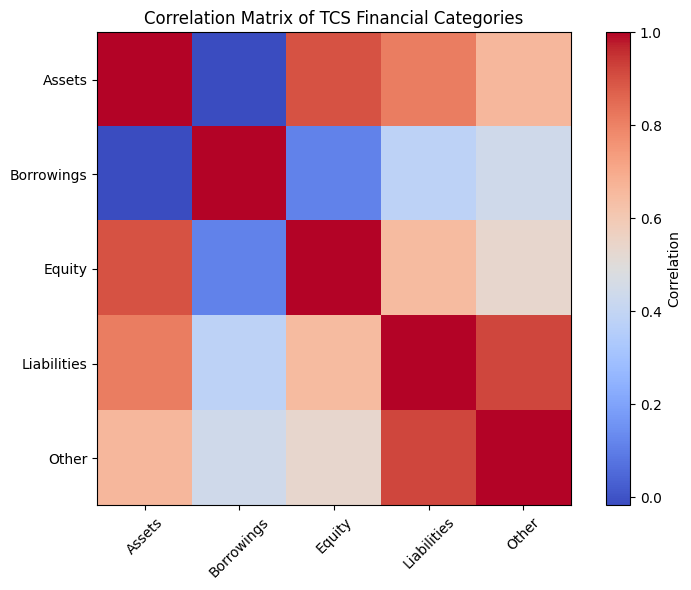

In [48]:
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = category_pivot.corr()

print(correlation_matrix)

# Plot correlation heatmap using matplotlib
plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title('Correlation Matrix of TCS Financial Categories')

plt.tight_layout()
plt.show()

## Business Interpretation

The correlation analysis measures how different financial categories move together over time.

* A correlation value close to **1** indicates a strong positive relationship.
* A value close to **0** indicates little or no relationship.
* A value close to **-1** indicates a strong negative relationship.

In the TCS financial dataset, a strong positive correlation between **Assets and Equity** would indicate that the company's asset growth has been supported primarily by shareholder funds rather than excessive borrowing. This is generally considered a positive indicator of long-term financial strength and stability.


## Financial Health Score

This section creates a simplified financial health score using major balance sheet categories. The score is designed to represent the overall financial strength of TCS based on the relationship between equity, assets, liabilities, and borrowings across reporting years.


In [50]:
# Create a working copy
health_df = category_pivot.copy()

# Ensure all required categories exist
for col in ['Equity', 'Assets', 'Liabilities', 'Borrowings']:
    if col not in health_df.columns:
        health_df[col] = 0

# Financial Health Score
health_df['Financial Health Score'] = (
    (health_df['Equity'] * 0.4) +
    (health_df['Assets'] * 0.3) -
    (health_df['Liabilities'] * 0.2) -
    (health_df['Borrowings'] * 0.1)
)

health_df.head()

Category,Assets,Borrowings,Equity,Liabilities,Other,Financial Health Score
Year,,,,,,
2004,214.26,588.81,94.16,17.58,100.62,39.545
2005,2335.24,1086.40,6964.19,1210.97,245.79,3135.414
2006,3685.51,1525.32,12006.73,1595.04,954.32,5436.805
2007,5694.38,2597.33,17758.24,2353.27,1046.44,8081.223
2008,6601.47,3841.62,24558.28,3174.55,1162.03,10784.681


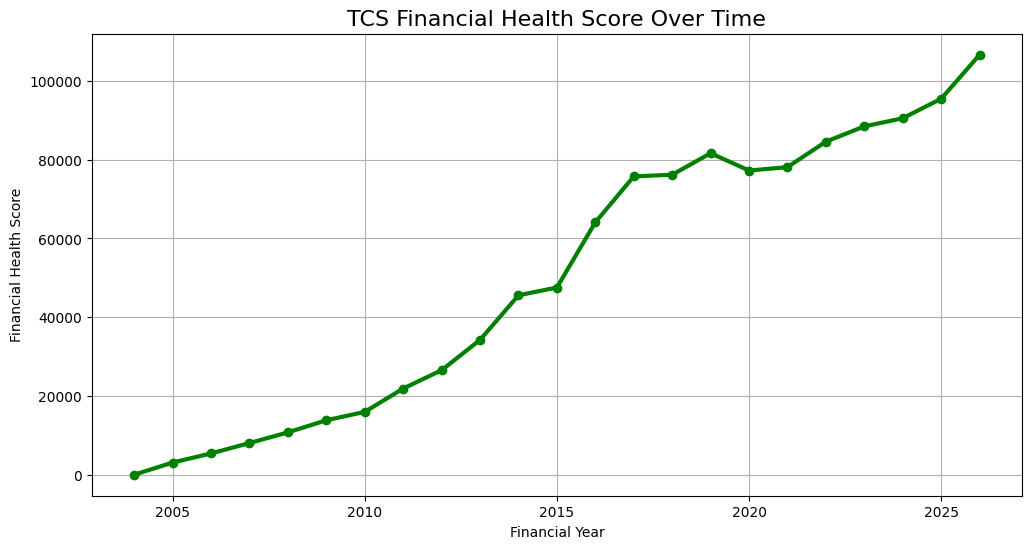

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(
    health_df.index,
    health_df['Financial Health Score'],
    marker='o',
    linewidth=3,
    color='green'
)

plt.title('TCS Financial Health Score Over Time', fontsize=16)
plt.xlabel('Financial Year')
plt.ylabel('Financial Health Score')
plt.grid(True)

plt.show()

In [53]:
best_years = (
    health_df['Financial Health Score']
    .sort_values(ascending=False)
    .head(5)
)

best_years

,Financial Health Score
Year,
2026,106630.276
2025,95468.576
2024,90508.876
2023,88446.940
2022,84566.640


## Business Interpretation

The financial health score combines equity strength, asset growth, liability exposure, and borrowing levels into a single analytical metric. Higher scores indicate stronger financial positioning and greater balance sheet stability. The highest-ranked years represent periods in which TCS demonstrated comparatively stronger financial resilience and capital strength.


## SQLite Database Integration

The cleaned TCS financial dataset is stored in a SQLite database to simulate a real-world financial reporting environment. This allows SQL-based business analysis and prepares the data for downstream Power BI integration.


In [54]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect('tcs_financial_analysis.db')

# Export cleaned financial data
tcs_clean.to_sql(
    'tcs_financials',
    conn,
    if_exists='replace',
    index=False
)

# Export financial health data
health_df.reset_index().to_sql(
    'financial_health',
    conn,
    if_exists='replace',
    index=False
)

print('SQLite database created successfully.')

SQLite database created successfully.


In [56]:
query = "SELECT name FROM sqlite_master WHERE type='table';"

tables = pd.read_sql_query(query, conn)

tables

,name
0,tcs_financials
1,financial_health


In [57]:
query = """
SELECT
    Indicator,
    ROUND(SUM(Amount), 2) AS Total_Amount
FROM tcs_financials
GROUP BY Indicator
ORDER BY Total_Amount DESC
LIMIT 10;
"""

top_sql = pd.read_sql_query(query, conn)

top_sql

,Indicator,Total_Amount
0,Total Reserves and Surplus,1226142.09
1,Reserves and Surplus,1226142.09
2,Trade Receivables,523469.68
3,Cash And Cash Equivalents,181903.39
4,Trade Payables,130323.55
5,Short Term Loans And Advances,83116.29
6,Short Term Provisions,40996.12
7,Long Term Loans And Advances,34968.79
8,Capital Work-In-Progress,30226.32
9,Minority Interest,12391.93


In [58]:
query = """
SELECT
    Year,
    ROUND(SUM(Amount), 2) AS Total_Financial_Amount
FROM tcs_financials
GROUP BY Year
ORDER BY Year;
"""

yearly_sql = pd.read_sql_query(query, conn)

yearly_sql

,Year,Total_Financial_Amount
0,2004,1015.43
1,2005,11842.59
2,2006,19766.92
3,2007,29449.66
4,2008,39337.95
5,2009,50268.46
6,2010,61538.35
7,2011,74056.06
8,2012,93591.35
9,2013,121101.58


Category-wise Financial Summary

In [59]:
query = """
SELECT
    Category,
    ROUND(SUM(Amount), 2) AS Total_Amount
FROM tcs_financials
GROUP BY Category
ORDER BY Total_Amount DESC;
"""

category_sql = pd.read_sql_query(query, conn)

category_sql

,Category,Total_Amount
0,Equity,2467407.97
1,Assets,705373.07
2,Liabilities,172813.93
3,Borrowings,122170.90
4,Other,43192.81


## Financial Health Ranking by Year

This SQL query ranks the financial years of TCS based on the calculated Financial Health Score, helping identify the strongest and weakest financial periods.


In [60]:
query = """
SELECT
    Year,
    ROUND([Financial Health Score], 2) AS Financial_Health_Score
FROM financial_health
ORDER BY [Financial Health Score] DESC;
"""

health_ranking = pd.read_sql_query(query, conn)

health_ranking

,Year,Financial_Health_Score
0,2026,106630.28
1,2025,95468.58
2,2024,90508.88
3,2023,88446.94
4,2022,84566.64
5,2019,81632.53
6,2021,78103.10
7,2020,77240.23
8,2018,76180.56
9,2017,75742.46


## Equity Growth Trend

This query tracks the year-wise movement of equity-related financial values to understand long-term shareholder capital growth.


In [61]:
query = """
SELECT
    Year,
    ROUND(SUM(Amount), 2) AS Equity_Amount
FROM tcs_financials
WHERE Category = 'Equity'
GROUP BY Year
ORDER BY Year;
"""

equity_sql = pd.read_sql_query(query, conn)

equity_sql

,Year,Equity_Amount
0,2004,94.16
1,2005,6964.19
2,2006,12006.73
3,2007,17758.24
4,2008,24558.28
5,2009,31358.06
6,2010,36989.34
7,2011,49065.52
8,2012,59214.36
9,2013,77347.36


## Borrowings Trend

This query evaluates the year-wise movement of borrowings to assess changes in financial leverage over time.


In [62]:
query = """
SELECT
    Year,
    ROUND(SUM(Amount), 2) AS Borrowings_Amount
FROM tcs_financials
WHERE Category = 'Borrowings'
GROUP BY Year
ORDER BY Year;
"""

borrowing_sql = pd.read_sql_query(query, conn)

borrowing_sql

,Year,Borrowings_Amount
0,2004,588.81
1,2005,1086.40
2,2006,1525.32
3,2007,2597.33
4,2008,3841.62
5,2009,5329.19
6,2010,5300.34
7,2011,4989.35
8,2012,6825.08
9,2013,11266.49


## Equity vs Liabilities Comparison

This query compares total equity and liabilities across financial years to evaluate the capital structure of TCS.


In [63]:
query = """
SELECT
    Year,
    Category,
    ROUND(SUM(Amount), 2) AS Total_Amount
FROM tcs_financials
WHERE Category IN ('Equity', 'Liabilities')
GROUP BY Year, Category
ORDER BY Year, Category;
"""

equity_liability_sql = pd.read_sql_query(query, conn)

equity_liability_sql

,Year,Category,Total_Amount
0,2004,Equity,94.16
1,2004,Liabilities,17.58
2,2005,Equity,6964.19
3,2005,Liabilities,1210.97
4,2006,Equity,12006.73
5,2006,Liabilities,1595.04
6,2007,Equity,17758.24
7,2007,Liabilities,2353.27
8,2008,Equity,24558.28
9,2008,Liabilities,3174.55


## SQL Executive Summary

This query generates a compact executive summary of the TCS financial database, including record count, year coverage, number of financial indicators, and total financial amount.


In [64]:
query = """
SELECT
    COUNT(*) AS Total_Records,
    COUNT(DISTINCT Year) AS Total_Years,
    COUNT(DISTINCT Indicator) AS Total_Indicators,
    ROUND(SUM(Amount), 2) AS Total_Financial_Amount
FROM tcs_financials;
"""

executive_summary = pd.read_sql_query(query, conn)

executive_summary

,Total_Records,Total_Years,Total_Indicators,Total_Financial_Amount
0,391,23,17,3510958.68


Export Data for Power BI

In [65]:
# Export cleaned financial dataset
tcs_clean.to_csv('tcs_clean_financial_data.csv', index=False)

# Export category trend data
category_trend.to_csv('tcs_category_trend.csv', index=False)

# Export yearly financial summary
yearly_summary.to_csv('tcs_yearly_summary.csv', index=False)

# Export financial health score
health_df.reset_index().to_csv('tcs_financial_health.csv', index=False)

# Export forecast data
forecast_df.to_csv('tcs_forecast.csv', index=False)

print('Power BI files exported successfully.')

Power BI files exported successfully.


In [67]:
from google.colab import files

files.download('tcs_clean_financial_data.csv')
files.download('tcs_category_trend.csv')
files.download('tcs_yearly_summary.csv')
files.download('tcs_financial_health.csv')
files.download('tcs_forecast.csv')
files.download('tcs_financial_analysis.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>